<a href="https://colab.research.google.com/github/NataliaPoluektova/MyFirstProject/blob/main/Lab1_CMSI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Лабораторна робота №1**
**Тема:** Парадигма обчислювальних графів, високорівневі абстракції шарів та інженерні компроміси в PyTorch

**Мета:** Освоїти наскрізний процес розробки ШІ-систем від нижнього рівня (атомарний обчислювальний граф) до верхнього рівня (модульні шари моделі). Навчитися аналізувати «Квадрат компромісів» шляхом практичного вимірювання затримки (Latency) та точності (Accuracy).

**Інженерний довідник (Теоретична база)**

Перед початком роботи розберемо 4 наріжні камені, на яких тримається проектування сучасних інтелектуальних систем:

1. Навчання з учителем (Supervised Learning) Це метод, при якому модель будує математичну функцію відображення вхідних ознак (X) у правильні відповіді (мітки Y), базуючись на історичних прикладах.

Аналогія: Це як підготовка студента до іспиту за збіркою завдань, де наприкінці книги є готові відповіді. Студент розв'язує задачу, порівнює свій результат із відповіддю, знаходить помилку і коригує логіку свого мислення.

2. Архітектура моделі (Model Architecture) Це структурна конфігурація нейронної мережі: кількість та типи її обчислювальних шарів, послідовність їхнього з'єднання, кількість внутрішніх параметрів (нейронів, ваг) та обрані функції активації.


Аналогія: Це архітектурне креслення хмарочоса або схема друкованої плати. Вона визначає, як саме будуть текти обчислювальні струми (дані) всередині системи. Неправильна схема призведе до того, що залізо або вийде з ладу через брак пам'яті, або не зможе вирішити поставлене завдання.

3. Графове представлення (Computational Graph)

Фреймворки (PyTorch, TensorFlow) бачать будь-яку модель як Орієнтований Ациклічний Граф (DAG). Вузли графа — це атомарні математичні операції (Mul, Add, ReLU), а ребра — тензори (багатовимірні масиви даних).

Аналогія: Це автоматизований конвеєр на заводі. Кожен верстат (вузол) виконує лише одну просту дію. Стрічки конвеєра (ребра) передають деталі від верстата до верстата строго в одному напрямку.

Ациклічність (відсутність петель) гарантує, що ми можемо розгорнути цей конвеєр у зворотному напрямку (Backpropagation) і чітко порахувати, який саме верстат припустився помилки.

4. Квадрат компромісів (The AI Trade-off Square) Фундаментальний закон проектування ШІ-систем: ви не можете одночасно отримати максимальну точність (Accuracy), мінімальну затримку (Latency), максимальну пропускну здатність (Throughput) та мінімальне енергоспоживання (Power). Оптимізація одного завжди б'є по інших.

Аналогія: Вибір автомобіля. Ви не можете купити машину, яка одночасно розганяється як болид Формули-1 (Latency = 0), перевозить 20 тонн вантажу (Throughput = +безкінечність), має броньований корпус захисту (Accuracy =100%$) і споживає 2 літри палива на 100 км (Power = min).

**Інженерна задача:**
Нам потрібно розробити інтелектуальну систему моніторингу для дата-центру. Задача моделі — спрогнозувати поточне завантаження CPU сервера (%) залежно від кількості активних користувачів у системі, щоб вчасно балансувати навантаження.Ми побудуємо найпростішу архітектуру — модель лінійної регресії:

y = xw + b

**Крок 1:**
Генерація та підготовка даних (Етап Навчання з учителем)
Згенеруємо синтетичну телеметрію сервера, де ми заздалегідь знаємо «ідеальну» залежність, але додамо до неї випадковий шум реального світу.

Тут використовується бібліотека PyTorch

*import torch (PyTorch)*

**PyTorch** — це провідний у світі інфраструктурний фреймворк глибокого навчання (Deep Learning) з відкритим вихідним кодом.

Він виконує дві головні функції в інженерії ШІ:

Робота з тензорами (як на CPU, так і на GPU):

Тензори — це багатовимірні матриці. PyTorch дозволяє переносити обчислення з центрального процесора (CPU) на графічний прискорювач (GPU) за допомогою однієї команди (наприклад, .to('cuda')), що прискорює множення матриць у сотні разів.

Автоматичне диференціювання (Autograd): Це ядро бібліотеки. Коли ви робите математичні операції з тензорами, у яких увімкнено requires_grad=True, PyTorch під капотом будує обчислювальний граф. Під час виклику loss.backward() фреймворк самостійно обчислює складні похідні за ланцюговим правилом. Розробнику не потрібно знати вищу математику для розрахунку градієнтів вручну.


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import time

# Фіксуємо seed для відтворюваності експериментів
torch.manual_seed(42)

# Генеруємо вхідну ознаку X (кількість користувачів від 10 до 100)
X = torch.linspace(10, 100, 100).unsqueeze(1)

# Генеруємо істинні мітки Y (CPU = X * 0.7 + 15 + випадковий шум реального світу)
noise = torch.randn(X.size()) * 5
Y_true = X * 0.7 + 15 + noise

# Візуалізуємо отримані дані
plt.figure(figsize=(7, 4))
plt.scatter(X.numpy(), Y_true.numpy(), color='blue', label='Телеметрія сервера (X, Y)')
plt.xlabel('Активні користувачі (Ознака X)')
plt.ylabel('Завантаження CPU % (Мітка Y)')
plt.title('Компонент: Навчання з учителем')
plt.legend()
plt.grid(True)
plt.show()

**Крок 1.2:** Ручне створення вузлів та ініціалізація Autograd
Ми створюємо тензори ваги w та зсуву b вручну. Прапорець requires_grad=True — це інструкція для PyTorch почати трекінг цих змінних у пам'яті для майбутнього розгортання графа у зворотному напрямку.

In [ ]:
w = torch.randn(1, requires_grad=True)
b = torch.randn(1, requires_grad=True)

print("--- Стан пам'яті (Нижній рівень) ---")
print(f"Вузол ваги w (Mul): {w.item():.4f}, відстеження градієнта: {w.requires_grad}")
print(f"Вузол зсуву b (Add): {b.item():.4f}, відстеження градієнта: {b.requires_grad}")

**Крок 1.3:** Ручний цикл навчання (Training Loop)

In [ ]:
learning_rate = 0.0001
epochs = 300
loss_history_manual = []

for epoch in range(epochs):
    # 1. FORWARD PASS: PyTorch створює в пам'яті вузли [Mul] та [Add]
    Y_pred = X * w + b

    # Створення фінального вузла функції втрат MSE Loss
    loss = torch.mean((Y_pred - Y_true) ** 2)
    loss_history_manual.append(loss.item())

    # 2. BACKPROPAGATION: Рушій Autograd розгортає граф назад від вузла loss
    # і записує обчислені похідні в комірки w.grad та b.grad
    loss.backward()

    # 3. ГРАДІЄНТНИЙ СПУСК (Оновлення параметрів заліза)
    # Блокуємо побудову графа для самих кроків віднімання через torch.no_grad()
    with torch.no_grad():
        w -= learning_rate * w.grad
        b -= learning_rate * b.grad

        # Ручне занулення градієнтів, щоб вони не накопичувалися в купу на наступній епосі
        w.grad.zero_()
        b.grad.zero_()

    if (epoch + 1) % 50 == 0:
        print(f"Епоха [{epoch+1}/{epochs}], Помилка (Loss): {loss.item():.4f}")

print(f"\nРезультат ручного графа: CPU = Користувачі * {w.item():.2f} + {b.item():.2f}")

**Частина 2. Верхній рівень:** Перехід до високорівневих шарів (Dense / nn.Linear)
Тепер подивимося, як цей самий процес реалізує професійний розробник ШІ. Ми замінимо ручне створення тензорів та математичних формул на один високорівневий шар архітектури — nn.Linear (повнозв'язний шар / Dense).

In [ ]:
import torch.nn as nn

# Створюємо архітектуру: 1 вхідна ознака -> 1 вихідний нейрон
# Об'єкт model автоматично створив всередині себе параметри w та b
model = nn.Linear(in_features=1, out_features=1)

# Замість ручного оновлення ваг використовуємо вбудований оптимізатор (SGD - стохастичний градієнтний спуск)
optimizer = torch.optim.SGD(model.parameters(), lr=0.0001)
# Стандартний критерій оцінки помилки MSE
criterion = nn.MSELoss()

loss_history_layer = []

print("--- Високорівнева абстракція шару ---")
print(model)
print("\nПараметри, приховані всередині шару:")
for name, param in model.named_parameters():
    print(f"-> {name}: {param.data.numpy()}")

print("\n--- Запуск навчання через шари ---")
for epoch in range(epochs):
    # 1. FORWARD PASS: Пропускаємо дані через абстракцію шару
    Y_pred = model(X)

    loss = criterion(Y_pred, Y_true)
    loss_history_layer.append(loss.item())

    # 2. BACKPROPAGATION
    optimizer.zero_grad() # Оптимізатор сам очищує пам'ять градієнтів для всіх внутрішніх ваг шару
    loss.backward()

    # 3. ОНОВЛЕННЯ ВАГ
    optimizer.step() # Оптимізатор сам робить крок градієнтного спуску для всього шару

    if (epoch + 1) % 50 == 0:
        print(f"Епоха [{epoch+1}/{epochs}], Помилка (Loss): {loss.item():.4f}")
for name, param in model.named_parameters():
    print(f"-> {name}: {param.data.numpy()}")

Завдання для самостійного виконання 1. Зміна швидкості навчання (Досліджуємо learning_rate)

Потрібно повернутися до Частини 2 (з шарами), змінити параметр learning_rate з 0.0001 на 0.01 (збільшити у 100 разів) і знову запустити навчання на ті самі 300 епох.

In [ ]:
##Код


**Висновки**

**Завдання для самостійного виконання 2** Додавання нової операції в ручний граф (Модифікація DAG)

Уявімо, що датчик сервера видає дані з систематичною похибкою — додає зайві 5% до навантаження. Студенту потрібно змінити ручний обчислювальний граф (Частина 1), вбудувавши туди нову операцію — віднімання константи 5.

Y_pred = (X * w + b) - 5

In [ ]:
##Код


**Висновки**

**Завдання для самостійного виконання 3** Експеримент із відключенням зсуву (bias = False)

model = nn.Linear(in_features=1, out_features=1, bias=False)

Як це вплине на якість прогнозу?

In [ ]:
##Код

**Висновки**

**Частина 3. Демонстрація «Квадрата компромісів» (The AI Trade-off Square**)

Щоб наочно побачити дію інженерного закону компромісів, проведемо експеримент.

Ми порівняємо дві різні архітектури систем:

Легка модель (Light Model): Наша навчена лінійна модель (мінімум обчислень, низька складність графа).

Важка модель (Heavy Model): Глибока нейромережа з багатьма прихованими шарами та тисячами нейронів (велика кількість операцій FLOP, висока складність графа).


Ми виміряємо дві метрики квадрата компромісів: Точність (MSE Loss) та Затримку (Latency) обробки пакету даних заліза в мілісекундах.


================ МЕТРИКИ КВАДРАТА КОМПРОМІСІВ ================
ЛЕГКА МОДЕЛЬ  | Помилка (менше=краще): 71.3253 | Затримка Latency: 0.015142 ms
ВАЖКА МОДЕЛЬ  | Помилка (менше=краще): 24.6476 | Затримка Latency: 1.560694 ms


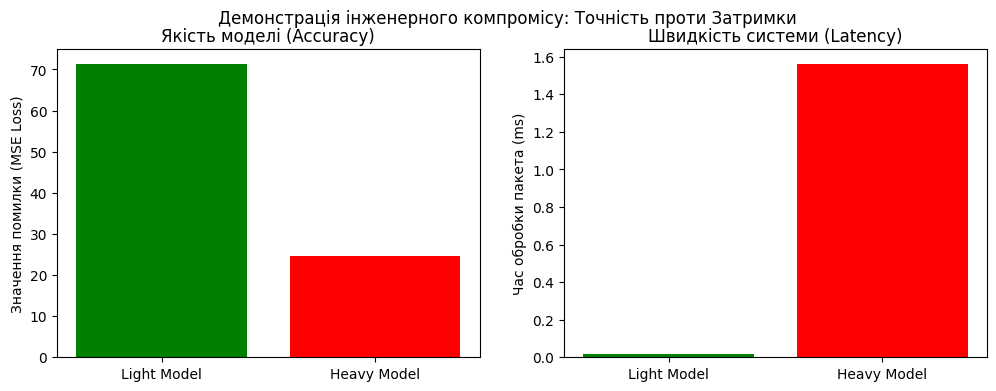

In [10]:
# 1. Проектуємо "Важку" архітектуру моделі (Deep Neural Network)
class HeavyModel(nn.Module):
    def __init__(self):
        super(HeavyModel, self).__init__()
        # Нагромаджуємо багато важких повнозв'язних шарів з активацією ReLU
        self.network = nn.Sequential(
            nn.Linear(1, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 1)
        )
    def forward(self, x):
        return self.network(x)

heavy_model = HeavyModel()
# Швидке тренування важкої моделі для демонстрації
heavy_optimizer = torch.optim.Adam(heavy_model.parameters(), lr=0.01)
for _ in range(200):
    heavy_optimizer.zero_grad()
    loss = criterion(heavy_model(X), Y_true)
    loss.backward()
    heavy_optimizer.step()

# 2. БЕНЧМАРКІНГ: Вимірюємо Latency та Accuracy для обох моделей
# Тестуємо Легку модель
start_time = time.time()
for _ in range(1000): # Проганяємо 1000 разів для точності заміру часу
    with torch.no_grad():
        pred_light = model(X)
loss_light = criterion(pred_light, Y_true).item()
latency_light = ((time.time() - start_time) / 1000) * 1000 # переводимо в мілісекунди (ms)

# Тестуємо Важку модель
start_time = time.time()
for _ in range(1000):
    with torch.no_grad():
        pred_heavy = heavy_model(X)
loss_heavy = criterion(pred_heavy, Y_true).item()
latency_heavy = ((time.time() - start_time) / 1000) * 1000

# 3. ВІЗУАЛІЗАЦІЯ КВАДРАТА КОМПРОМІСІВ
print("\n================ МЕТРИКИ КВАДРАТА КОМПРОМІСІВ ================")
print(f"ЛЕГКА МОДЕЛЬ  | Помилка (менше=краще): {loss_light:.4f} | Затримка Latency: {latency_light:.6f} ms")
print(f"ВАЖКА МОДЕЛЬ  | Помилка (менше=краще): {loss_heavy:.4f} | Затримка Latency: {latency_heavy:.6f} ms")
print("==============================================================")

# Побудова порівняльних діаграм
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.bar(['Light Model', 'Heavy Model'], [loss_light, loss_heavy], color=['green', 'red'])
ax1.set_ylabel('Значення помилки (MSE Loss)')
ax1.set_title('Якість моделі (Accuracy)')

ax2.bar(['Light Model', 'Heavy Model'], [latency_light, latency_heavy], color=['green', 'red'])
ax2.set_ylabel('Час обробки пакета (ms)')
ax2.set_title('Швидкість системи (Latency)')

plt.suptitle('Демонстрація інженерного компромісу: Точність проти Затримки')
plt.show()

**Завдання для самостійного виконання 4**

Уявіть, що ви розгортаєте цю систему моніторингу всередині дрібного контролера IoT (Edge-пристрій) з жорстким лімітом акумулятора та слабким процесором. Яку з двох моделей (Light чи Heavy) ви оберете для інтеграції і чому? Якими параметрами Квадрата компромісів ви пожертвуєте у цьому сценарії?

**Ваш аналіз:**